In [3]:
!pip install pandas numpy matplotlib wordcloud scikit-learn tensorflow

  Using cached pandas-3.0.2-cp311-cp311-win_amd64.whl (9.9 MB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
  Using cached wordcloud-1.9.6-cp311-cp311-win_amd64.whl (306 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.w

In [4]:
# Cell 1
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [5]:
# Cell 2
df = pd.read_csv('data/data_raw.csv')
df = df[df['komentar'].notna()]

df.head()

,komentar,timestamp,platform
0,"Minusnya gopay, susah menghubungi layanan CS a...",5 hari yang lalu,youtube
1,Cantik☺️,2 bulan yang lalu,youtube
2,MANTAP MBK review nya,4 bulan yang lalu,youtube
3,Semoga segera bangkrut kau perusahaan tipu tip...,5 bulan yang lalu,youtube
4,Lebih baik jangan pakai gopay ujung ujungnya h...,5 bulan yang lalu,youtube


In [6]:
# Cell 3
positif_words = ["bagus","aman","cepat","mantap","keren"]
negatif_words = ["buruk","error","hilang","jelek","parah"]
negasi_words = ["tidak","gak","nggak","bukan"]

def get_sentiment(text):
    text = str(text).lower()
    words = text.split()
    score = 0

    for i, word in enumerate(words):
        if word in negasi_words and i+1 < len(words):
            next_word = words[i+1]
            if next_word in positif_words:
                score -= 1
            elif next_word in negatif_words:
                score += 1

        if word in positif_words:
            score += 1
        elif word in negatif_words:
            score -= 1

    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

df['sentimen'] = df['komentar'].apply(get_sentiment)

df['sentimen'].value_counts()

sentimen
netral     869
positif     79
negatif     32
Name: count, dtype: int64

In [7]:
# Cell 4
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['komentar'].apply(clean_text)

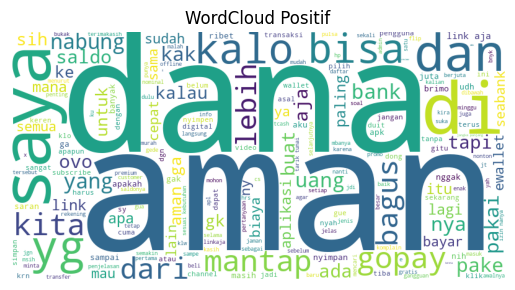

In [8]:
# Cell 5
text_pos = " ".join(df[df['sentimen']=="positif"]['clean'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud Positif")
plt.show()

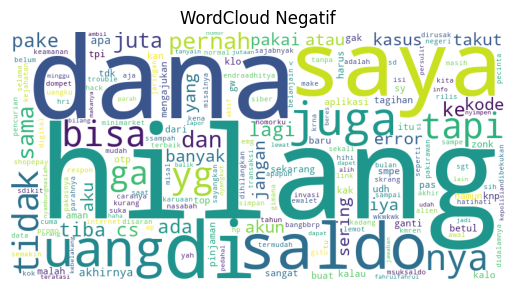

In [9]:
# Cell 6
text_neg = " ".join(df[df['sentimen']=="negatif"]['clean'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud Negatif")
plt.show()

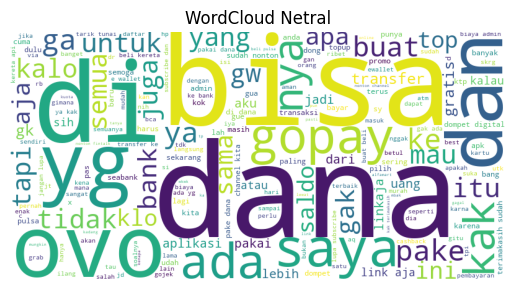

In [11]:
# Cell 7
text_net = " ".join(df[df['sentimen']=="netral"]['clean'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_net)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud Netral")
plt.show()

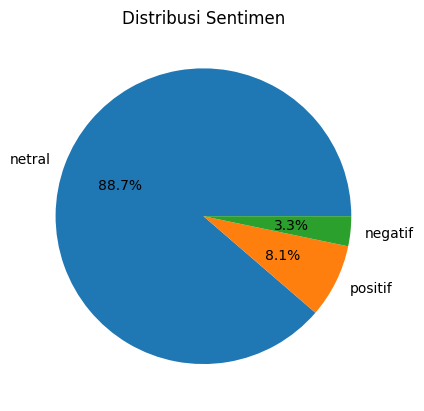

In [12]:
# Cell 8
df['sentimen'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Sentimen")
plt.show()